#  ***🫀 Cardiovascular Risk Prediction – Framingham Study***
**Author**: Dominykas Babičas

**Date**: May 2026

### 📌 **What this project covers**

- Loading and inspecting the Framingham cardiovascular dataset

- Checking data types, missing values, and duplicates

- Handling outliers and skewed medical variables (winsorization, log transforms)

- Exploring key risk factors: age, sex, smoking, BMI, blood pressure, glucose, diabetes

- Visualizing CHD imbalance and risk patterns across subgroups

- Analyzing correlations before and after cleaning

- Building a logistic regression pipeline with preprocessing

- Optimizing decision threshold with a focus on recall for CHD cases

- Generating predicted probabilities and final CHD risk flags

### 🛠️ **Libraries used**

***Pandas — data loading, cleaning, and manipulation*** 
Used to read the dataset, inspect structure, handle missing values, engineer features, and compute descriptive statistics.

***NumPy — numerical operations***
Supports array‑based transformations, log operations, winsorization logic, and metric calculations.

***Matplotlib — core plotting***
Provides base figures, axis control, and layout management for all visualizations.

***Seaborn — statistical visualizations***
Used for histograms, boxplots, countplots, and heatmaps to explore distributions and relationships between risk factors and CHD.

***Plotly — interactive visualizations***
Adds dynamic, zoomable charts for deeper exploration of distributions, correlations, and risk patterns.

***Scikit‑learn — modeling and evaluation***
Used for preprocessing (imputers, encoders, ColumnTransformer), building a logistic regression pipeline, computing metrics (AUC, classification report), ROC curves, and threshold tuning.

***Warnings — suppressing non‑critical output***
Keeps the notebook clean by hiding unnecessary warnings.

***OS — operating system utilities***

### 🧾 **Data Brief**

This dataset comes from the **Framingham Heart Study**, a long‑running cardiovascular cohort study.
Each row represents a patient with demographic, behavioral, and clinical risk factors, along with a binary 10‑year CHD outcome.

Key variables include:

- **age** — Patient age in years

- **sex** — Biological sex (M/F)

- **is_smoking** — Current smoking status

- **cigsPerDay** — Average cigarettes smoked per day

- **BPMeds** — On blood pressure medication

- **prevalentStroke** — History of stroke

- **prevalentHyp** — Hypertension status

- **diabetes** — Diabetes status

- **totChol** — Total cholesterol

- **sysBP** / **diaBP** — Systolic and diastolic blood pressure

- **BMI** — Body Mass Index

- **heartRate** — Resting heart rate

- **glucose** — Fasting blood glucose

- **TenYearCHD** — Target variable (1 = CHD event within 10 years, 0 = none)

### 🧩 **Data Limitations & Assumptions**

- **No Time‑Based Information**
The dataset provides only a single snapshot of each patient’s health, with no history or duration of conditions. We assume these measurements are stable and representative.

- **No Measurement Context**
Variables like glucose and blood pressure lack information about fasting state, rest conditions, or medication timing. We assume all measurements were taken under comparable clinical conditions.

- **Imbalanced Target Variable**
Only ~15% of patients develop CHD, making the dataset highly imbalanced. We assume recall‑focused evaluation is appropriate because missing CHD cases is clinically riskier.

- **Self‑Reported Behavioral Variables**
Smoking status and cigarettes per day are self‑reported and may contain bias. We assume these values are sufficiently accurate for modeling.

- **Preprocessing Assumptions**
Winsorization and log transformations reduce skew and stabilize the model but introduce assumptions about the distribution of medical variables. We assume these transformations preserve clinically meaningful patterns.

- **Limited Generalizability**
The dataset represents a specific population from Framingham, Massachusetts. We assume the patterns generalize reasonably well, but real‑world performance may differ across demographics.

- **Education Level Ordering**
 We assume that Education Level 1 represents the lowest level of education and Level 4 represents the highest, based on the dataset documentation and typical ordinal encoding. This ordering is treated as meaningful in the model.

# 📚 Data Loading, Basic Exploration & Data Cleaning

## 📈 ***1. Data Loading***

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plo

import warnings
warnings.filterwarnings('ignore')

import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    precision_score, 
    recall_score, 
    f1_score, 
    confusion_matrix
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    precision_recall_curve,
)



## 🧮 ***2 .Basic Exploration ("train.csv")*** 

Because this project uses *two separate datasets* (train.csv and test.csv), the exploration approach is intentionally different for each to avoid data leakage and keep the workflow clean.

In [2]:
test = pd.read_csv("test.csv")
train = pd.read_csv("train.csv")
train.head()


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   str    
 4   is_smoking       3390 non-null   str    
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9), int64(6), 

In [4]:
train.duplicated().sum()

np.int64(0)

In [5]:
train.isna().sum().sort_values(ascending=False)

glucose            304
education           87
BPMeds              44
totChol             38
cigsPerDay          22
BMI                 14
heartRate            1
id                   0
age                  0
prevalentHyp         0
prevalentStroke      0
sex                  0
is_smoking           0
diaBP                0
sysBP                0
diabetes             0
TenYearCHD           0
dtype: int64

In [6]:
missing_percent = (train.isna().sum() / len(train)) * 100
missing_percent = missing_percent.sort_values(ascending=False).round(2)

missing_df = pd.DataFrame({
    "Feature": missing_percent.index,
    "Missing_%": missing_percent.values
})

missing_df


,Feature,Missing_%
0,glucose,8.97
1,education,2.57
2,BPMeds,1.30
3,totChol,1.12
4,cigsPerDay,0.65
5,BMI,0.41
6,heartRate,0.03
7,id,0.00
8,age,0.00
9,prevalentHyp,0.00


### 🧩 **Missing Values**

Several clinical variables contain missing entries (e.g., glucose, education, BPMeds).

These missing values will be handled later through imputation inside the modeling pipeline, ensuring no leakage and consistent preprocessing.

Also we see that only **Glucose** has significant missing value numbers **9%**. Other factors have **low-impact missingness***

## 🛞 ***4. Data Exploration***

### 🟦 4.1 Distribution of the target variable (CHD imbalance)

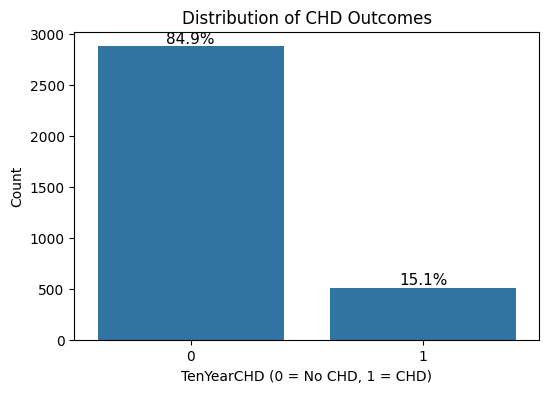

In [7]:
plt.figure(figsize=(6,4))
ax = sns.countplot(data=train, x="TenYearCHD")

# Calculate percentages
total = len(train)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f"{percentage:.1f}%", 
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom', fontsize=11)

plt.title("Distribution of CHD Outcomes")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("Count")
plt.show()


The target **TenYearCHD** is strongly imbalanced: **~85% no CHD** vs **~15% CHD**.

This makes accuracy misleading, so the model prioritizes **recall** and uses **threshold** tuning to better detect CHD cases.

### 📜 4.2 Age distribution + CHD vs Age

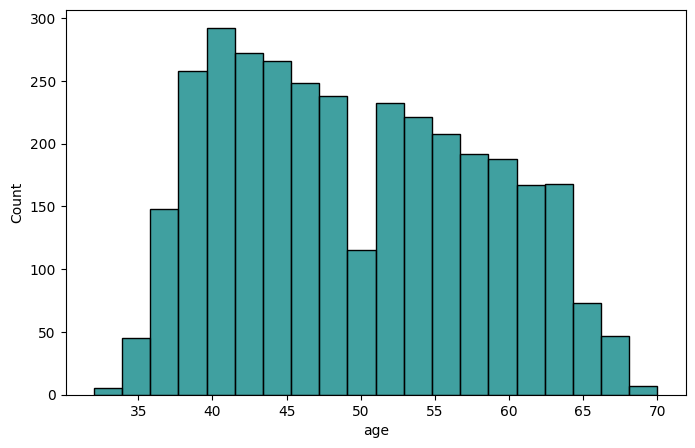

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["age"],
    bins=20,
    color="teal",
    edgecolor="black"
)

plt.title
plt.show()

Age is concentrated around the early 40s, with most individuals between 35–55.

The distribution is smooth and unimodal, with no extreme skew.

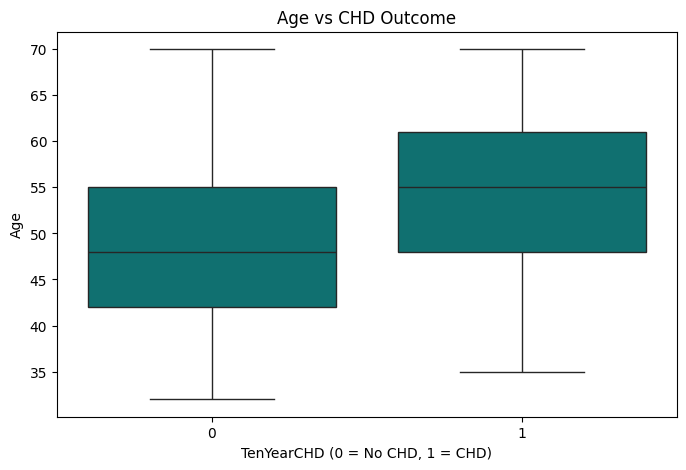

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="age",
    color="teal"      # teal boxplot
)

plt.title("Age vs CHD Outcome")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("Age")
plt.show()


Individuals who developed CHD tend to be older than those who did not.

The median age for CHD‑positive cases is noticeably higher, and the distribution shows a clear upward shift.

This confirms that age is a strong predictor of CHD and will likely have a significant positive coefficient in the logistic regression model.

### ❤️ 4.3 Sex Distribution + CHD vs Sex

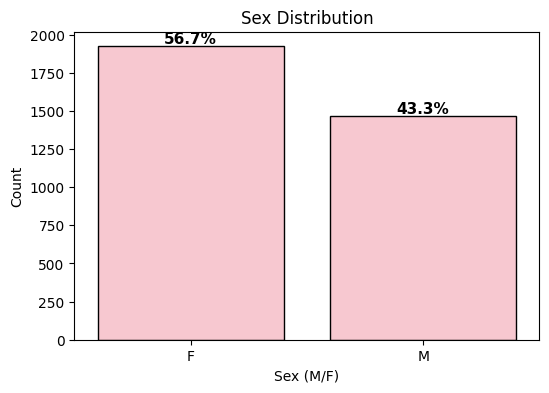

In [10]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=train,
    x="sex",
    color="pink",
    edgecolor="black"
)

# Add % labels
total = len(train)
for p in ax.patches:
    count = p.get_height()
    percentage = f"{100 * count/total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2, count),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Sex Distribution")
plt.xlabel("Sex (M/F)")
plt.ylabel("Count")
plt.show()


The dataset contains more females than males, with women making up the larger share of the sample.

This imbalance is important to keep in mind when examining CHD risk factors by sex.

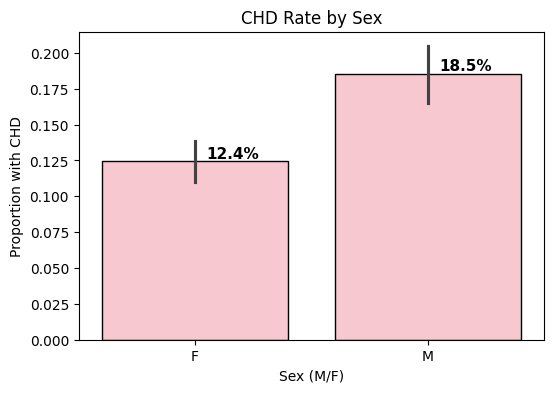

In [11]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=train,
    x="sex",
    y="TenYearCHD",
    estimator="mean",
    color="pink",
    edgecolor="black"
)


for p in ax.patches:
    value = p.get_height()
    percentage = f"{value*100:.1f}%"
    
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2 + 0.05, value),   
        ha='left',                                     
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("CHD Rate by Sex")
plt.xlabel("Sex (M/F)")
plt.ylabel("Proportion with CHD")
plt.show()


- Males have a higher CHD rate (18.5%)

- Females have a lower CHD rate (12.4%)

The vertical lines on each bar represent 95% confidence intervals, indicating the uncertainty around the estimated mean CHD rate.

Although the dataset contains **more females than males**, the CHD rate is calculated within each sex group, so the imbalance does not distort the comparison — it only affects the precision of the estimates. 

Overall, males exhibit a meaningfully higher prevalence of CHD, consistent with clinical evidence that men tend to develop CHD earlier due to hormonal, metabolic, and lifestyle factors. 

This indicates that **sex is a meaningful predictor** and will likely contribute to the logistic regression model.

### 🚬 4.4 Smoking Behavior and CHD Risk

***4.4.1 Smoking Status Distribution***

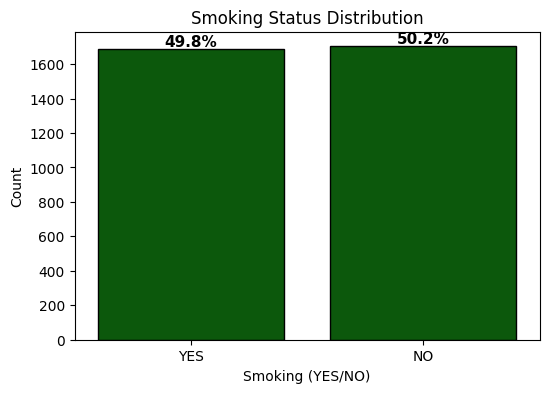

In [12]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=train,
    x="is_smoking",
    color="darkgreen",
    edgecolor="black"
)

# Add % labels
total = len(train)
for p in ax.patches:
    count = p.get_height()
    percentage = f"{100 * count/total:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, count),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Smoking Status Distribution")
plt.xlabel("Smoking (YES/NO)")
plt.ylabel("Count")
plt.show()


The dataset contains a similar number of smokers and non‑smokers. 

This balance is useful because it allows the model to learn the effect of smoking without strong class imbalance in this feature.

***4.4.2 CHD Rate by Smoking Status***

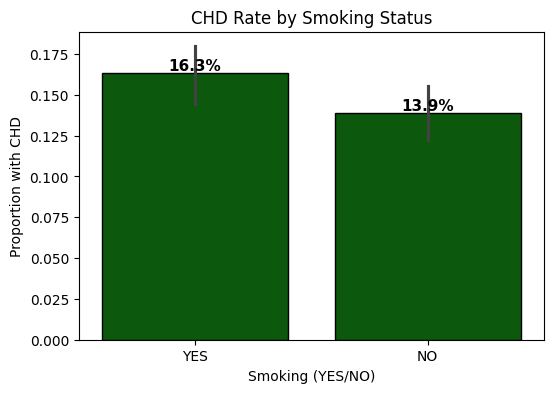

In [13]:
plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=train,
    x="is_smoking",
    y="TenYearCHD",
    estimator="mean",
    color="darkgreen",     
    edgecolor="black"      
)

# Add % labels
for p in ax.patches:
    value = p.get_height()
    percentage = f"{value*100:.1f}%"
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, value),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("CHD Rate by Smoking Status")
plt.xlabel("Smoking (YES/NO)")
plt.ylabel("Proportion with CHD")
plt.show()


Smokers show a **higher CHD rate (16.3%)** compared to non‑smokers **(13.9%)**. The vertical lines represent 95% confidence intervals, indicating the uncertainty around each estimate. 


Although the difference is modest, the direction is consistent with clinical evidence: smoking increases cardiovascular strain, accelerates atherosclerosis, and elevates long‑term CHD risk. 

This makes smoking status a **meaningful predictor** that will likely contribute to the logistic regression model.

***4.4.3 Cigarettes Per Day (Among Smokers)***

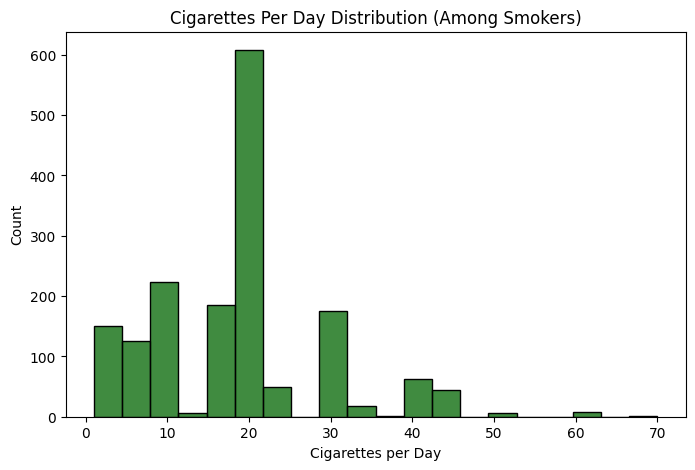

In [14]:
smokers = train[train["is_smoking"] == "YES"]

plt.figure(figsize=(8,5))

ax = sns.histplot(
    smokers["cigsPerDay"],
    bins=20,
    color="darkgreen",
    edgecolor="black",
    kde=False
)

plt.title("Cigarettes Per Day Distribution (Among Smokers)")
plt.xlabel("Cigarettes per Day")
plt.ylabel("Count")

plt.show()


Smokers show a clear peak around **20 cigarettes per day**, with most falling into the light‑to‑moderate range and a smaller tail of heavier smokers. 

The right‑skewed shape highlights meaningful variation in smoking intensity, which sets up the next step: examining whether heavier smoking corresponds to higher CHD risk.

***4.4.4 CHD vs Cigarettes Per Day (Among Smokers)***

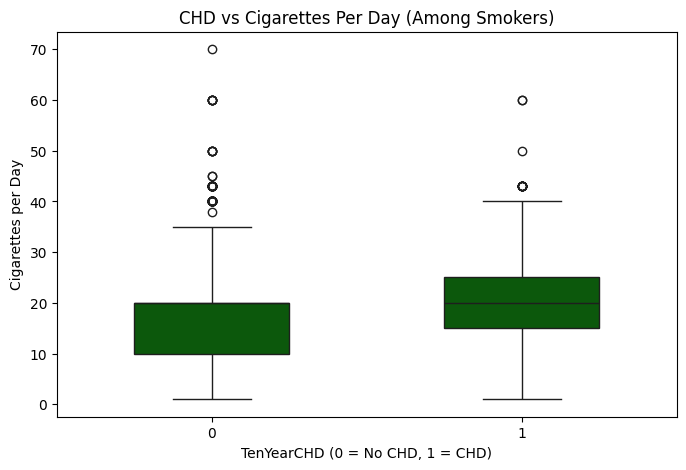

In [15]:
smokers = train[train["is_smoking"] == "YES"]

plt.figure(figsize=(8,5))

sns.boxplot(
    data=smokers,
    x="TenYearCHD",
    y="cigsPerDay",
    color="darkgreen",
    width=0.5
)

plt.title("CHD vs Cigarettes Per Day (Among Smokers)")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("Cigarettes per Day")
plt.show()


Smokers who developed CHD tend to smoke **slightly more cigarettes per day**, but the overlap between groups is substantial.

A few heavy‑smoker outliers appear in both categories, suggesting that while higher consumption may contribute to risk, smoking intensity alone is not a strong standalone predictor. 

This points to a **weak dose–response pattern**, complementing the clearer difference observed in the binary smoking comparison.

### 👁️ 4.5 BMI Distribution + CHD vs BMI

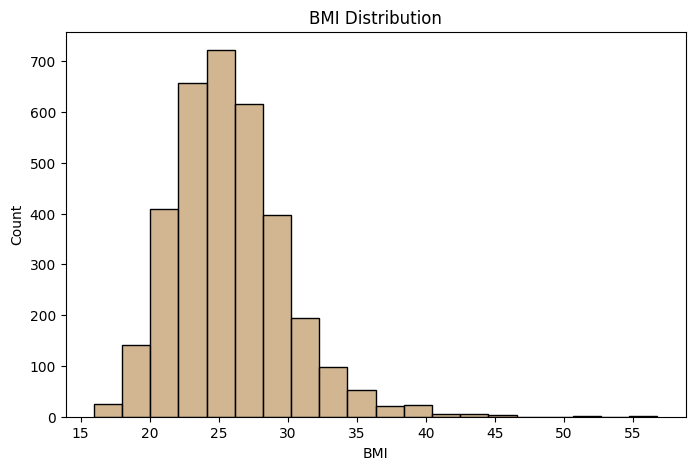

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["BMI"],
    bins=20,
    kde=False,
    color="#C49E6C",      
    edgecolor="black"
)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()


BMI shows a right‑skewed distribution centered around the mid‑20s, with values ranging roughly from 15 to above 50. 

A noticeable upper tail reflects a small group of individuals with higher BMI, creating natural outliers. 

Overall, the distribution captures realistic variation in body composition across the cohort.

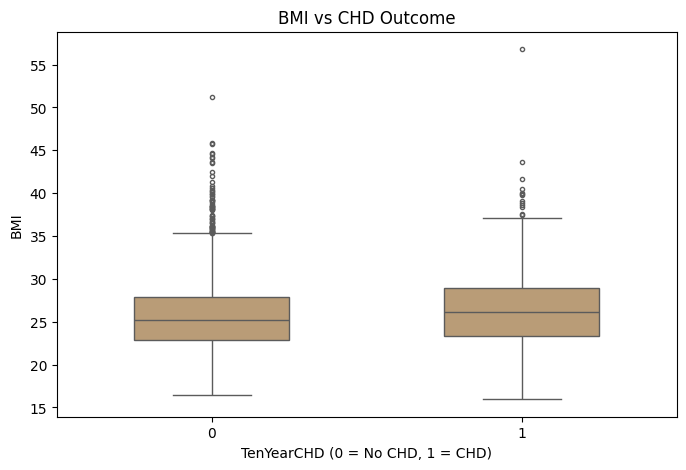

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="BMI",
    color="#C49E6C",   # same soft tan as the histogram
    width=0.5,
    fliersize=3
)

plt.title("BMI vs CHD Outcome")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("BMI")
plt.show()


BMI distributions for CHD‑positive and CHD‑negative individuals are highly similar. 

Both groups share nearly identical medians and interquartile ranges, with substantial overlap across the full BMI spectrum.

A few high‑BMI outliers appear in each group, but they do not form a clear separation. 

Overall, BMI shows only a weak visual distinction between CHD outcomes.

### 🌪️ 4.6 Cholesterol Distribution + CHD vs Cholesterol

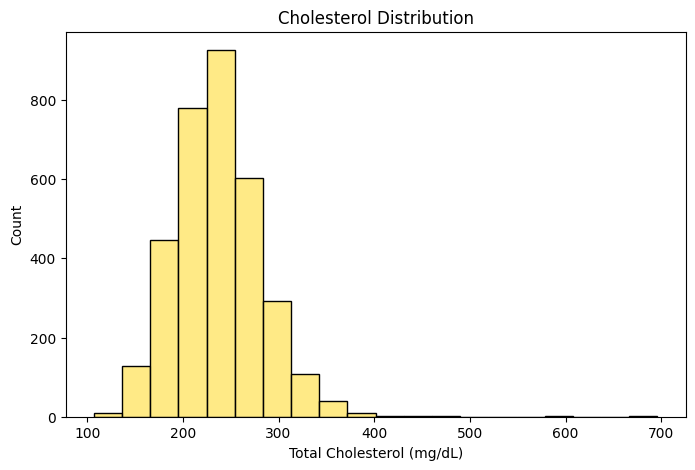

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["totChol"],
    bins=20,
    kde=False,
    color="#FFE45E",     # bright lemon yellow
    edgecolor="black"
)

plt.title("Cholesterol Distribution")
plt.xlabel("Total Cholesterol (mg/dL)")
plt.ylabel("Count")
plt.show()


Total cholesterol shows a right‑skewed distribution, with most values falling between **150 and 300 mg/dL** and a long tail extending toward higher clinical values. 

The peak around **240–260 mg/dL** reflects typical population patterns, while the upper tail captures individuals with elevated cholesterol levels. 

This spread provides meaningful variation for assessing cardiovascular risk.

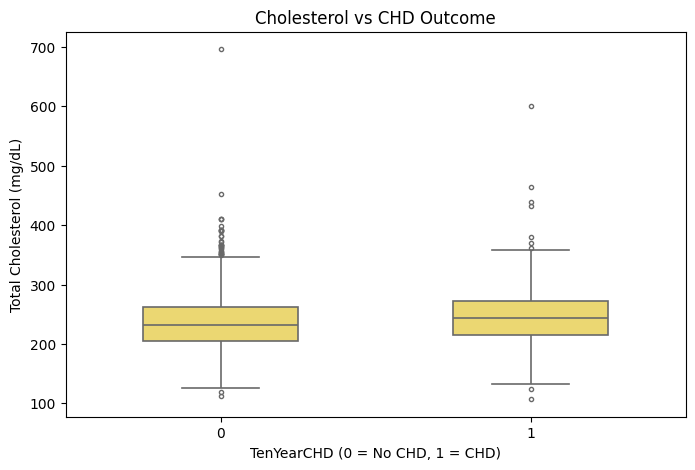

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="totChol",
    color="#FFE45E", 
    width=0.5,
    fliersize=3,
    linewidth=1.2
)

plt.title("Cholesterol vs CHD Outcome")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("Total Cholesterol (mg/dL)")
plt.show()


Cholesterol levels are broadly similar between individuals with and without CHD. 

Both groups share nearly identical medians and interquartile ranges, with substantial overlap across the full distribution.

A few high‑cholesterol outliers appear in each group, but they do not form a clear separation. 

Overall, cholesterol shows only a weak visual relationship with CHD in this dataset.

### 🔵 4.7 Metabolic Health: Diabetes & Glucose

4.7.1 Diabetes Distribution

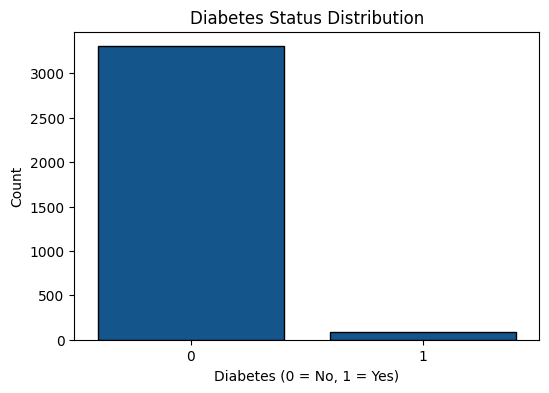

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="diabetes",
    color="#0057A0",
    edgecolor="black"
)

plt.title("Diabetes Status Distribution")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


Diabetes is rare in this dataset, with only a small fraction of individuals diagnosed. 

This imbalance is important context for interpreting glucose levels and CHD risk, as most metabolic variation occurs within the non‑diabetic majority.

4.7.2 CHD rate by Diabetes Distribution

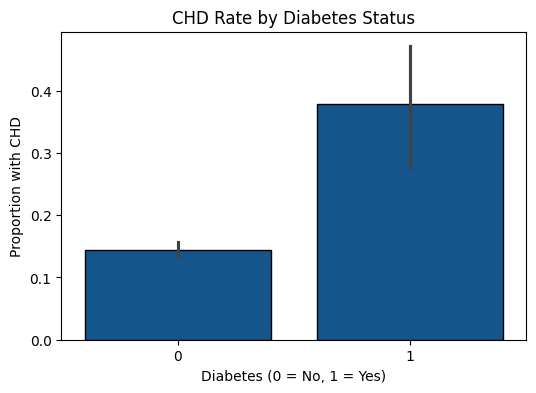

In [21]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=train,
    x="diabetes",
    y="TenYearCHD",
    estimator="mean",
    color="#0057A0",
    edgecolor="black"
)

plt.title("CHD Rate by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Proportion with CHD")
plt.show()


Individuals with diabetes show a substantially higher rate of CHD compared to those without diabetes. 

Although the diabetic group is small, the difference in CHD proportion is large, highlighting diabetes as a meaningful cardiovascular risk factor even in an imbalanced dataset.

4.7.3 Glucose Distribution (Diabetes Only)

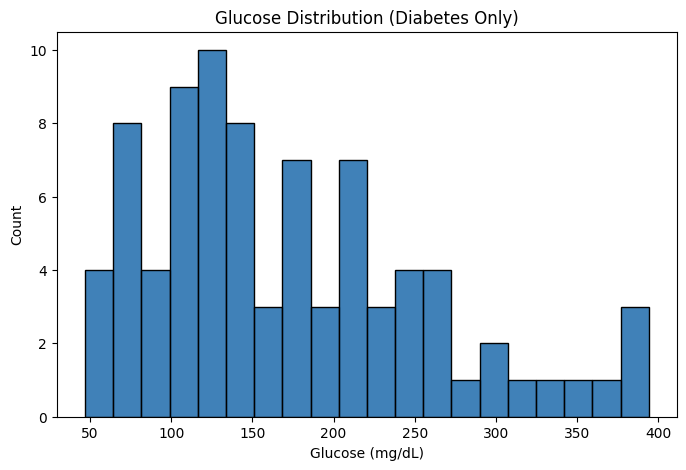

In [22]:
# Filter diabetics only
diabetics = train[train["diabetes"] == 1]

plt.figure(figsize=(8,5))
sns.histplot(
    diabetics["glucose"],
    bins=20,
    color="#0057A0", 
    edgecolor="black"
)

plt.title("Glucose Distribution (Diabetes Only)")
plt.xlabel("Glucose (mg/dL)")
plt.ylabel("Count")
plt.show()


Glucose levels among diabetic individuals show a clear right‑skewed distribution, with most values concentrated in the moderately elevated range and a smaller number extending into very high levels. 

This pattern reflects varying degrees of glycemic control within the diabetic subgroup and provides meaningful context for evaluating CHD risk.

4.7.4  Glucose vs CHD Outcome (Diabetes Only)

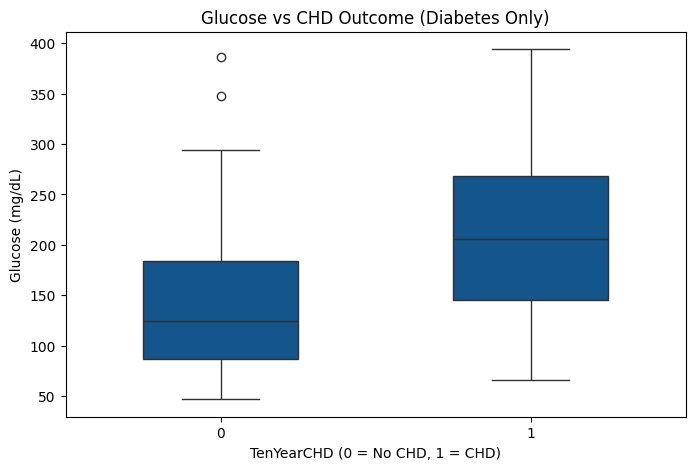

In [23]:
diabetics = train[train["diabetes"] == 1]

plt.figure(figsize=(8,5))
sns.boxplot(
    data=diabetics,
    x="TenYearCHD",
    y="glucose",
    color="#0057A0",
    width=0.5
)

plt.title("Glucose vs CHD Outcome (Diabetes Only)")
plt.xlabel("TenYearCHD (0 = No CHD, 1 = CHD)")
plt.ylabel("Glucose (mg/dL)")
plt.show()


Among diabetic individuals, those with CHD exhibit higher glucose levels, with a noticeably elevated median and a broader upper range compared to CHD‑negative diabetics. 



### 🩸 4.8 Blood Pressure distribution (sysBP & diaBP) + CHD rate

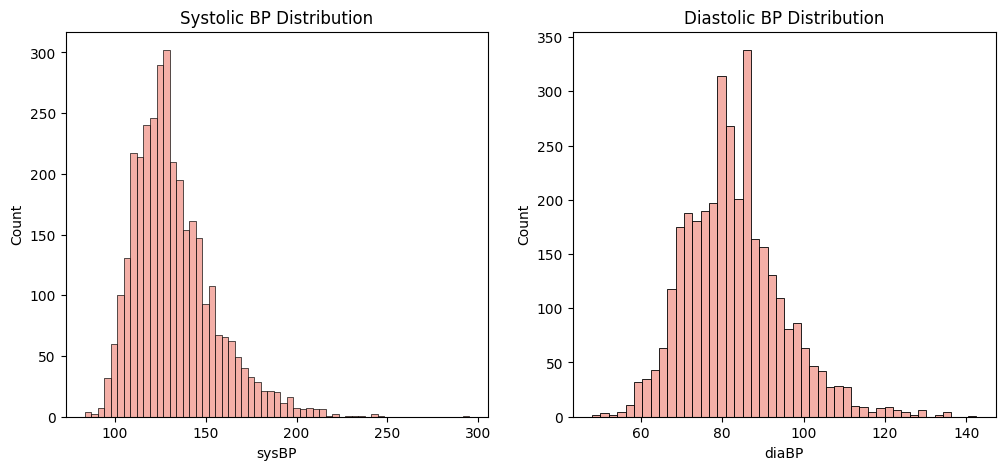

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(train['sysBP'], kde=False, color="#F1948A")
plt.title("Systolic BP Distribution")
plt.xlabel("sysBP")

plt.subplot(1,2,2)
sns.histplot(train['diaBP'], kde=False, color="#F1948A")
plt.title("Diastolic BP Distribution")
plt.xlabel("diaBP")

plt.tight_layout
plt.show()

Systolic and diastolic blood pressure were analyzed together, as they represent complementary aspects of cardiovascular function. 

Both variables show right‑skewed distributions with clinically plausible ranges. The effect is stronger for systolic BP. 

Overall, elevated blood pressure—particularly systolic—emerges as one of the most important risk factors in the dataset.

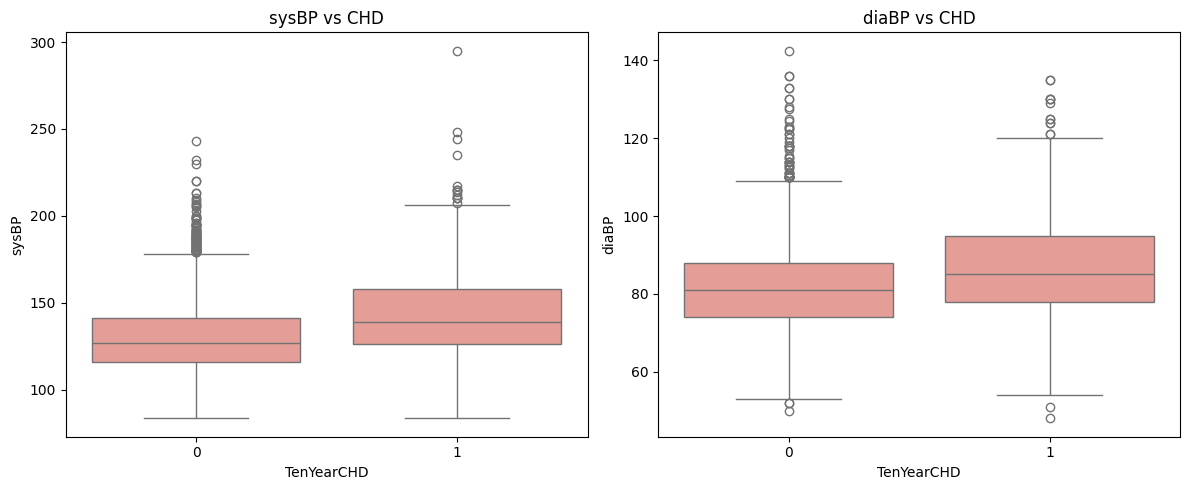

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="sysBP",
    palette=["#F1948A", "#F1948A"]
)
plt.title("sysBP vs CHD")

plt.subplot(1,2,2)
sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="diaBP",
    palette=["#F1948A", "#F1948A"]
)
plt.title("diaBP vs CHD")

plt.tight_layout()
plt.show()


Systolic and diastolic blood pressure were analyzed together, as they represent complementary aspects of cardiovascular function. 

Both distributions show clinically plausible right‑skewed patterns, with systolic BP centered around **130 mmHg** and diastolic BP around **80 mmHg**.

**When comparing CHD outcomes, individuals who developed CHD exhibit noticeably higher systolic and diastolic pressures.**

Overall, elevated blood pressure—particularly systolic—emerges as one of the most influential risk factors in the dataset.

### 💊 4.9 Blood Pressure Medication distribution + CHD vs BPmeds

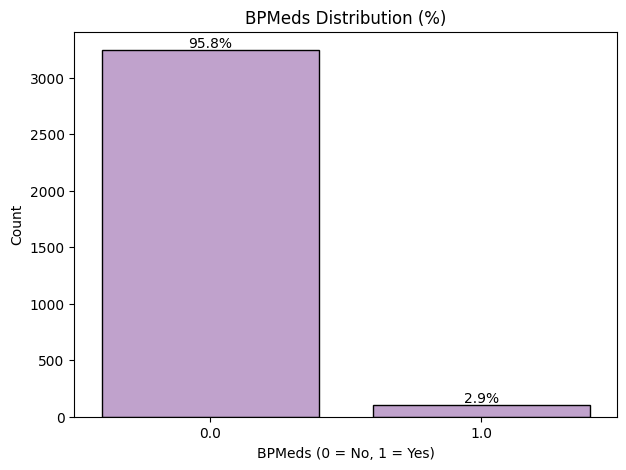

In [26]:
plt.figure(figsize=(7,5))
ax = sns.countplot(
    data=train,
    x="BPMeds",
    color="#C39BD3",   # light purple
    edgecolor="black"
)

total = len(train)
for p in ax.patches:
    count = p.get_height()
    pct = 100 * count / total
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width()/2, count),
                ha='center', va='bottom')

plt.title("BPMeds Distribution (%)")
plt.xlabel("BPMeds (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


The dataset is highly imbalanced with respect to blood‑pressure medication usage. 

Approximately **95.8%** of individuals report not taking antihypertensive medication, while only **2.9%** are currently treated.

This small treated subgroup represents participants with a documented history of elevated blood pressure, making BPMeds a useful proxy for underlying hypertension severity.

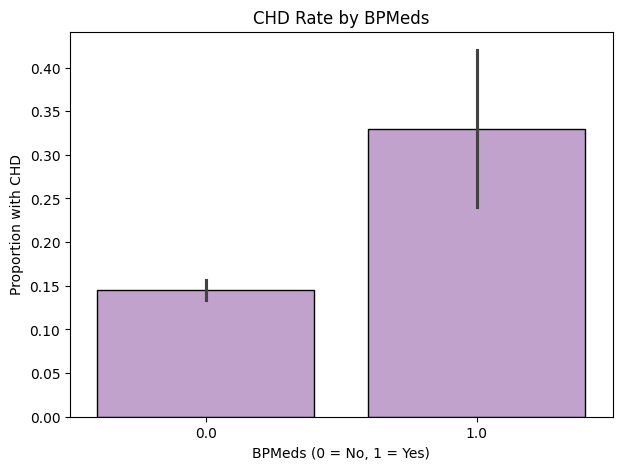

In [27]:
plt.figure(figsize=(7,5))
sns.barplot(
    data=train,
    x="BPMeds",
    y="TenYearCHD",
    estimator="mean",
    color="#C39BD3",   # light purple
    edgecolor="black"
)

plt.title("CHD Rate by BPMeds")
plt.xlabel("BPMeds (0 = No, 1 = Yes)")
plt.ylabel("Proportion with CHD")
plt.show()


Individuals taking blood‑pressure medication show a substantially higher CHD prevalence compared to those not on treatment. 

**The medication itself is not the cause of increased CHD risk; rather, it reflects the underlying severity of their blood‑pressure condition.**

Despite the small size of the treated group, the difference in CHD rates is large enough to make BPMeds a meaningful contextual variable in the overall risk profile.

### 📈 4.10 Heart Rate Distribution + CHD vs Heart Rate

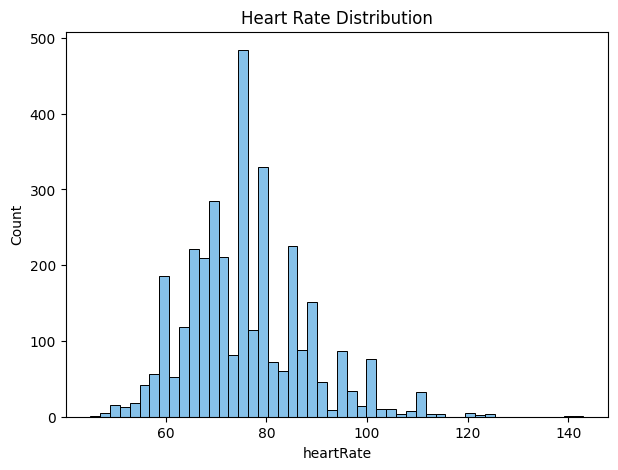

In [28]:
plt.figure(figsize=(7,5))
sns.histplot(train['heartRate'], kde=False, color="#5DADE2")
plt.title("Heart Rate Distribution")
plt.xlabel("heartRate")
plt.ylabel("Count")
plt.show()


Resting heart rate shows a centered, fairly symmetric distribution, with most values clustering around **70–80 bpm**. 

The tail toward higher heart rates is short, indicating that elevated resting pulse is relatively uncommon in the dataset. 

**Overall, the distribution reflects typical population patterns and provides a stable baseline for assessing cardiovascular strain.**


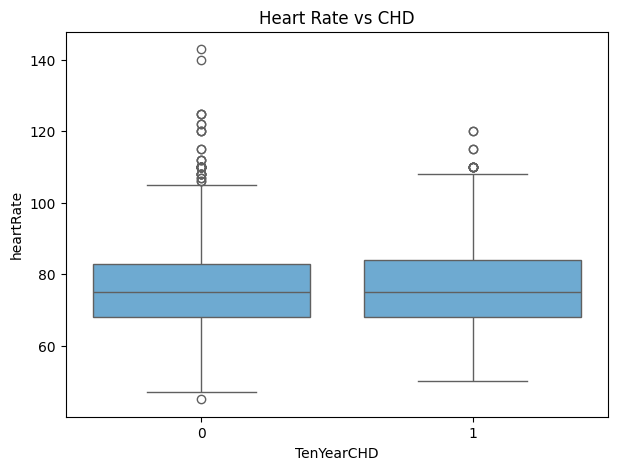

In [29]:
plt.figure(figsize=(7,5))
sns.boxplot(
    data=train,
    x="TenYearCHD",
    y="heartRate",
    palette=["#5DADE2", "#5DADE2"]
)
plt.title("Heart Rate vs CHD")
plt.xlabel("TenYearCHD")
plt.ylabel("heartRate")
plt.show()


Resting heart rate shows only a weak relationship with CHD. The distributions for CHD‑positive and CHD‑negative individuals overlap heavily, with similar medians and ranges.

Although CHD‑positive individuals may show slightly higher values on average, the difference is small and inconsistent.

Overall, heart rate is a minor predictor compared to stronger factors such as age & blood pressure.

### 📙 4.11 Education Distribution + CHD vs Education

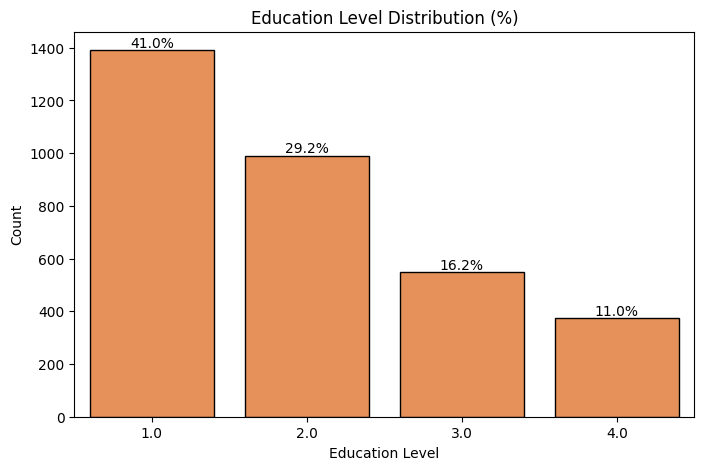

In [30]:
plt.figure(figsize=(8,5))
ax = sns.countplot(
    data=train,
    x="education",
    color="#FF8C42",
    edgecolor="black"
)

# Calculate percentages
total = len(train)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f"{percentage:.1f}%",
                (p.get_x() + p.get_width() / 2, count),
                ha='center', va='bottom', fontsize=10)

plt.title("Education Level Distribution (%)")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.show()


Education levels in the dataset show a clear decreasing pattern, with the majority of individuals concentrated in the lowest education category

Specifically, Level 1 accounts for **41%** of the population, followed by Level 2 at **29.2%**, Level 3 at **16.2%**, and Level 4 at **11%**.

This imbalance indicates that higher number of participants have lower formal education, which may influence lifestyle & health literacy.

The distribution is sufficiently populated across all categories to support further CHD‑related analysis.

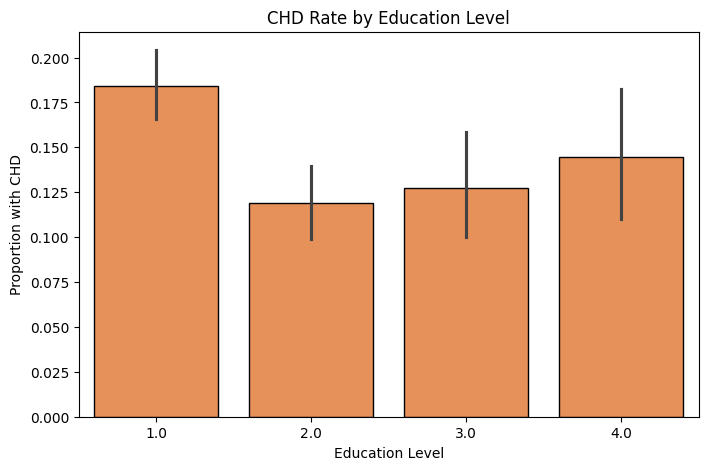

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=train,
    x="education",
    y="TenYearCHD",
    estimator="mean",
    color="#FF8C42",   # warm orange
    edgecolor="black"
)

plt.title("CHD Rate by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Proportion with CHD")
plt.show()


Education shows a non‑linear relationship with CHD.

Individuals with the lowest education level have the highest CHD prevalence, but the lowest risk is observed at Level 2 rather than at the highest education levels.

This suggests that education alone does not fully explain cardiovascular risk and may interact with other socioeconomic or lifestyle factors.

### 4.12 ✳️ Correlation

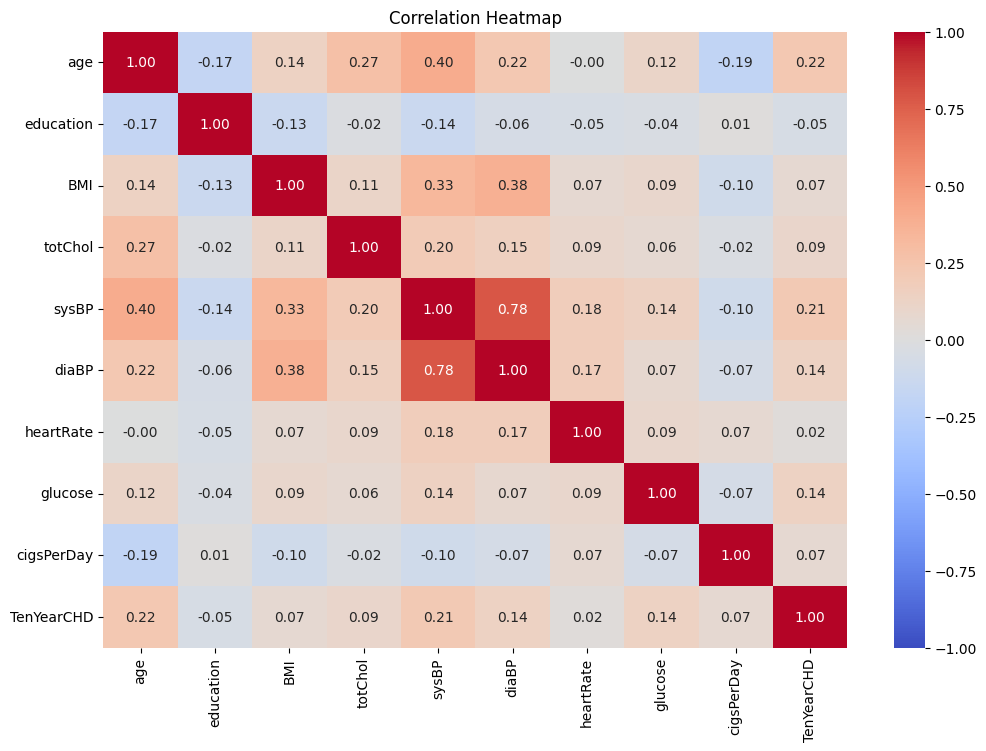

In [32]:
raw_corr_vars = [
    "age",
    "education",
    "BMI",
    "totChol",
    "sysBP",
    "diaBP",
    "heartRate",
    "glucose",
    "cigsPerDay",
    "TenYearCHD"
]

raw_corr_df = train[raw_corr_vars]

raw_corr_matrix = raw_corr_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    raw_corr_matrix,
    annot=True,          # ← adds numbers
    fmt=".2f",           # ← formats numbers to 2 decimals
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap")
plt.show()


To understand how key variables relate to each other and to Ten‑Year CHD risk, I computed a Pearson correlation matrix using the raw dataset (with outliers). 

The heatmap highlights the main linear relationships:

- **Age**, **blood pressure**, and **glucose** show the strongest positive links with CHD.

- Education shows mild negative associations with several risk factors.

- Lifestyle variables (e.g., **cigsPerDay**) show only weak correlations.

### 🏁 4.13 Outliers

In [33]:
continuous_vars = ["age", "BMI", "totChol", "sysBP", "diaBP", "cigsPerDay", "heartRate", "glucose"]

outlier_summary = {}

for col in continuous_vars:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # statistical outliers
    stat_outliers = train[(train[col] < lower) | (train[col] > upper)]
    
    # clinical rules
    clinical_rules = {
        "sysBP": train[train["sysBP"] > 200],
        "diaBP": train[train["diaBP"] > 120],
        "heartRate": train[train["heartRate"] > 120],
        "glucose": train[train["glucose"] > 200]
    }
    
    clinical_outliers = clinical_rules.get(col, pd.DataFrame())
    
    # data quality rules
    dq_rules = {
        "BMI": train[(train["BMI"] < 15) | (train["BMI"] > 50)],
        "cigsPerDay": train[train["cigsPerDay"] > 40],
        "heartRate": train[train["heartRate"] < 40]
    }
    
    dq_outliers = dq_rules.get(col, pd.DataFrame())
    
    outlier_summary[col] = {
        "lower_bound": lower,
        "upper_bound": upper,
        "stat_outliers": len(stat_outliers),
        "clinical_outliers": len(clinical_outliers),
        "data_quality_outliers": len(dq_outliers)
    }

pd.DataFrame(outlier_summary).T


,lower_bound,upper_bound,stat_outliers,clinical_outliers,data_quality_outliers
age,21.00,77.00,0.0,0.0,0.0
BMI,15.49,35.57,77.0,0.0,2.0
totChol,119.00,351.00,43.0,0.0,0.0
sysBP,76.50,184.50,105.0,35.0,0.0
diaBP,51.25,113.25,58.0,29.0,0.0
cigsPerDay,-30.00,50.00,9.0,0.0,59.0
heartRate,45.50,105.50,64.0,7.0,0.0
glucose,47.00,111.00,158.0,28.0,0.0


- ***Statistical Outliers*** — Values flagged using the IQR rule (below Q1 − 1.5×IQR or above Q3 + 1.5×IQR). These represent mathematical extremes in the dataset, regardless of clinical meaning.

- ***Clinical Outliers*** — Values exceeding medically recognized thresholds (e.g., glucose > 126 mg/dL, sysBP > 180 mmHg). These represent clinically abnormal cases, even if they are not statistically extreme.

- ***Data‑Quality Outliers*** — Values that are impossible or invalid (e.g., negative BMI, cigarettes/day < 0, diastolic > systolic). These indicate data entry errors rather than real patient characteristics.

Outlier detection was performed across all continuous variables using the IQR method, complemented by clinical and data‑quality thresholds. 

**Systolic** and **diastolic** **blood pressure** showed the highest number of extreme values, followed by **glucose** and **BMI**. 

Clinical outliers were most frequent in blood pressure and glucose, reflecting physiologically abnormal readings rather than data errors. 

Data‑quality outliers were limited to **BMI** and **cigsPerDay**, suggesting occasional entry inconsistencies. 

Overall, the dataset contains a manageable number of outliers, most of which represent genuine clinical extremes rather than noise.


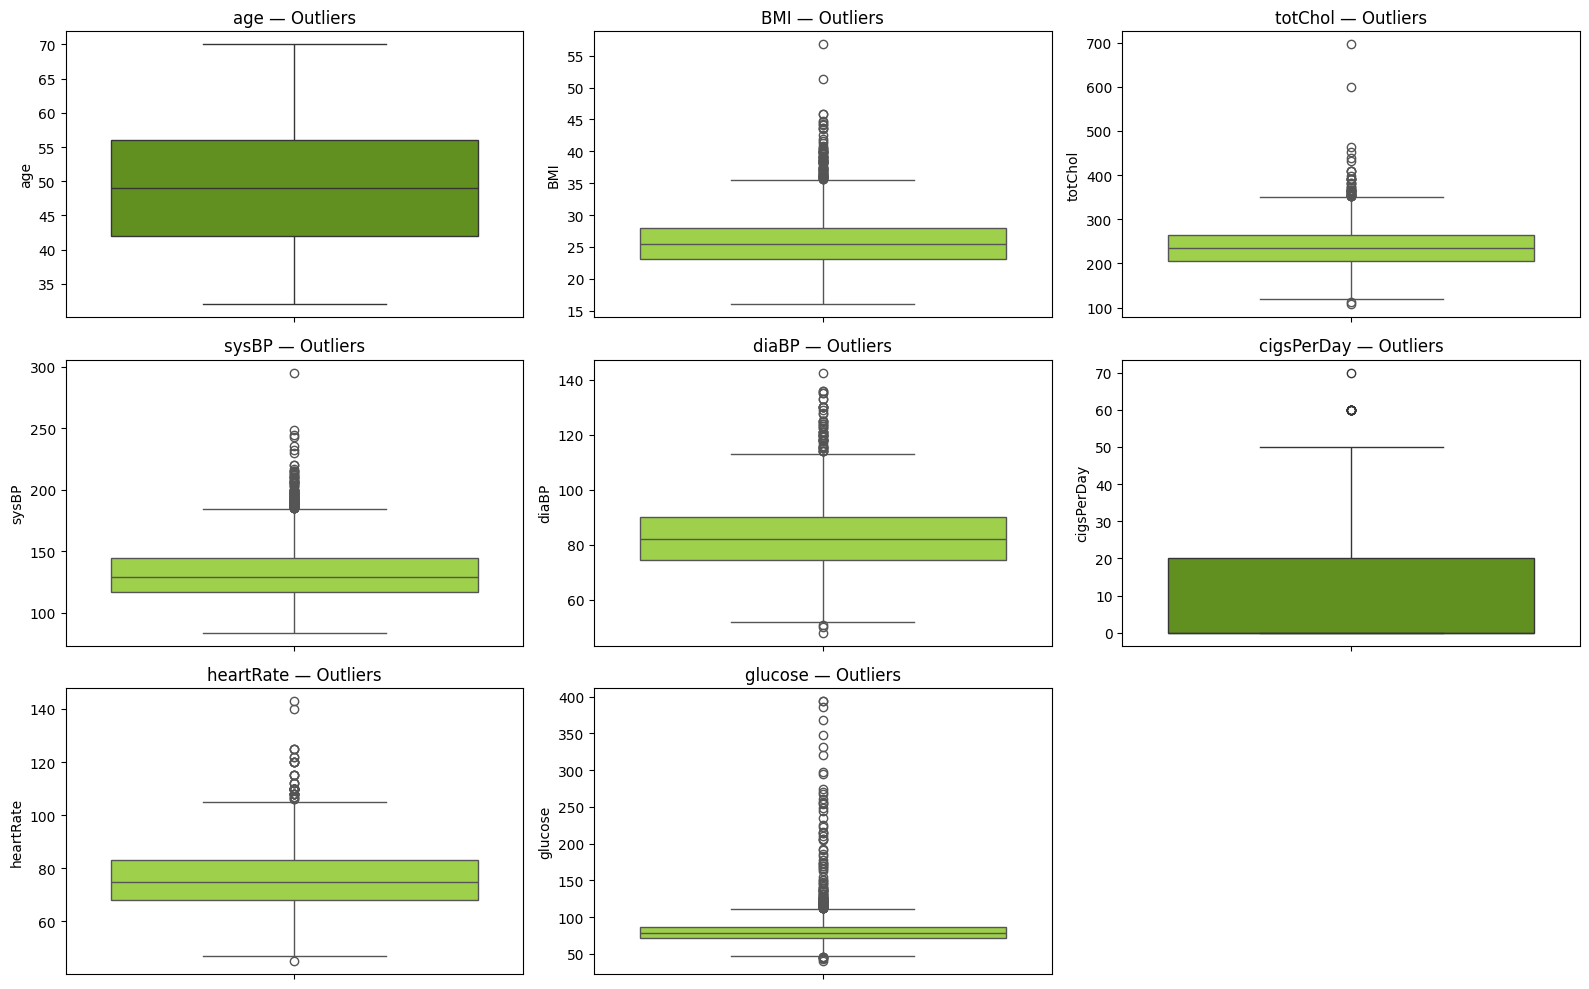

In [34]:
highlight_vars = ["sysBP", "diaBP", "glucose", "BMI", "heartRate", "totChol"]

plt.figure(figsize=(16, 10))

for i, col in enumerate(continuous_vars, 1):
    plt.subplot(3, 3, i)
    
    # important → bright lime, others → deep lime
    color = "#A3E635" if col in highlight_vars else "#65A30D"
    
    sns.boxplot(
        data=train,
        y=col,
        color=color
    )
    
    plt.title(f"{col} — Outliers", fontsize=12)

plt.tight_layout()
plt.show()


The boxplots highlight substantial outlier presence in **systolic and diastolic blood pressure**, **glucose**, **BMI**, **cholesterol** and **heart rate**, consistent with the earlier numerical summary. 

Variables such as **age** show minimal deviation, while **cigsPerDay** displays a long right tail driven by heavy smokers. 

These visual patterns confirm that most outliers represent genuine clinical extremes rather than data-entry errors.


In [35]:
def get_outlier_mask(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (df[col] < lower) | (df[col] > upper)

outlier_masks = {col: get_outlier_mask(train, col) for col in continuous_vars}

train["sex"] = train["sex"].map({"M": 1, "F": 0})

profiles = {}

for col, mask in outlier_masks.items():
    subset = train[mask]
    profiles[col] = {
        "num_outliers": len(subset),
        "CHD_rate": subset["TenYearCHD"].mean(),
        "avg_age": subset["age"].mean(),
        "pct_male": subset["sex"].mean()
    }

pd.DataFrame(profiles).T


,num_outliers,CHD_rate,avg_age,pct_male
age,0.0,NaN,NaN,NaN
BMI,77.0,0.220779,52.506494,0.168831
totChol,43.0,0.279070,54.046512,0.255814
sysBP,105.0,0.390476,57.828571,0.238095
diaBP,58.0,0.431034,55.172414,0.327586
cigsPerDay,9.0,0.222222,49.222222,1.000000
heartRate,64.0,0.203125,49.734375,0.343750
glucose,158.0,0.310127,52.993671,0.481013



To understand who falls into the extreme ends of each distribution, statistical outliers were identified using the IQR rule for all continuous variables. 

This method flags observations lying below *Q1 − 1.5·IQR* or above *Q3 + 1.5·IQR*, capturing values that are unusually distant from the central mass of the data.

**This profiling helps determine whether statistical outliers represent meaningful subpopulations (e.g., older, higher‑risk individuals) or simply distributional extremes without clinical relevance.**

The resulting table provides a concise overview of how extreme values differ demographically and clinically, guiding later decisions on preprocessing and model robustness.

### ⭐ 4.14 EDA Summary

The dataset was explored across demographic, lifestyle, clinical, and medical‑history variables to understand patterns associated with 10‑year CHD risk. Several variables showed clear, clinically consistent relationships with CHD, while others contributed weaker or more indirect signals.

- #### **Demographics**
Age showed one of the strongest associations with CHD, with risk increasing steadily across older groups. Sex differences were present, with men exhibiting higher CHD prevalence.

- #### **Lifestyle Factors**
Smoking behavior displayed a right‑skewed distribution, with a minority of heavy smokers. CHD prevalence was higher among smokers, and slightly elevated among heavier smokers. BMI and heart rate contributed additional lifestyle‑related signal.

- #### **Clinical Measures**
Blood pressure variables (sysBP and diaBP) were among the most influential predictors. Individuals with CHD had noticeably higher systolic and diastolic pressures, with systolic BP showing the clearest separation. Glucose levels were also elevated among CHD‑positive individuals within the diabetic subgroup.

- #### **Medical History**
Variables such as diabetes, and blood‑pressure medication aligned with higher CHD prevalence, reinforcing their clinical relevance.

- #### **Correlation Structure**
A Pearson correlation matrix revealed several meaningful linear relationships:

- Age, systolic BP, diastolic BP, and glucose showed the strongest positive correlations with CHD.

- Education showed mild negative correlations with several risk factors.

- Lifestyle variables such as cigsPerDay exhibited only weak linear relationships.

These correlations provide a baseline understanding of how predictors interact before any preprocessing.

- #### **Outliers**
Outlier analysis identified extreme values across several continuous variables. Blood pressure, glucose, BMI, cholesterol and heart rate contained the most pronounced outliers, many of which represent genuine clinical extremes rather than data‑entry errors. 

- #### **Overall Pattern**
The EDA highlights a consistent clinical picture: CHD risk increases with age, elevated blood pressure, smoking intensity, glucose abnormalities, and markers of existing cardiovascular strain. These findings align with established medical literature and provide a strong foundation for preprocessing and model development.

## 🧼 ***5 Data Preprocessing (Cleaning & Transformation)***

### 🫧 5.1 Creating the Clean Training Dataset

Before applying any preprocessing steps, a separate working copy of the training data is created. 

This ensures that all transformations—such as winsorization, log‑scaling, and feature engineering—are applied only to the clean dataset, while the original train remains intact for reference and comparison.

In [36]:
train_clean = train.copy()

### 🪵 5.2 Log Transformations (Reducing Skew)

In [37]:
log_vars = ["BMI", "totChol", "glucose", "cigsPerDay"]

for col in log_vars:Several continuous medical variables in the dataset—such as **glucose**, **totChol**, **BMI**, and **cigsPerDay—exhibit** - exhibit right‑skewed distributions. Right‑skew can weaken model performance by:

- stretching the scale of extreme values

- reducing the influence of central observations

- violating linearity assumptions in logistic regression

To stabilize variance and improve linear relationships with CHD, a natural log transformation was applied to selected variables. A small constant (+1) is added where needed to avoid issues with zero values.

Only variables with meaningful right‑skew were transformed; **blood pressure** variables were excluded because their clinical interpretation is clearer on the original scale.
    train_clean[f"log_{col}"] = np.log1p(train_clean[col])


SyntaxError: invalid character '—' (U+2014) (2911800809.py, line 3)

### 🗔 5.3 Winsorization

In [ ]:
def winsorize_series(s, lower, upper):
    return s.clip(lower=lower, upper=upper)

# Winsorize mild/noisy outliers
train_clean["BMI"] = winsorize_series(train["BMI"], 
                                outlier_summary["BMI"]["lower_bound"], 
                                outlier_summary["BMI"]["upper_bound"])

train_clean["cigsPerDay"] = winsorize_series(train["cigsPerDay"], 
                                       outlier_summary["cigsPerDay"]["lower_bound"], 
                                       outlier_summary["cigsPerDay"]["upper_bound"])

train_clean["heartRate"] = winsorize_series(train["heartRate"], 
                                      outlier_summary["heartRate"]["lower_bound"], 
                                      outlier_summary["heartRate"]["upper_bound"])

# Winsorize only upper tail for clinically meaningful variables
train_clean["sysBP"] = train["sysBP"].clip(upper=outlier_summary["sysBP"]["upper_bound"])
train_clean["diaBP"] = train["diaBP"].clip(upper=outlier_summary["diaBP"]["upper_bound"])
train_clean["glucose"] = train["glucose"].clip(upper=outlier_summary["glucose"]["upper_bound"])


To reduce the influence of extreme values while preserving clinically meaningful observations, selected continuous variables were winsorized using the IQR‑based thresholds identified during EDA. 

This approach caps only the most extreme values rather than removing rows, ensuring that high‑risk patients remain in the dataset while preventing outliers from destabilizing the model.

- **BMI, cigsPerDay, heartRate**  
  These variables contain mild or noisy statistical outliers. Both tails were winsorized using IQR‑based lower and upper bounds.

- **sysBP, diaBP, glucose**  
  These variables contain clinically meaningful high-end values. To preserve real medical risk patterns, only the extreme upper tail was capped.


This approach keeps EDA and preprocessing clearly separated, stabilizes the data for modeling, and maintains the clinical interpretability of key cardiovascular risk variables.


### ♨️ 5.4 Correlation without Outliers

In [ ]:
clean_corr_matrix = train_clean[[
    "age", "BMI", "totChol",
    "sysBP", "diaBP",
    "heartRate", "log_glucose",
    "cigsPerDay", "TenYearCHD"
]].corr()


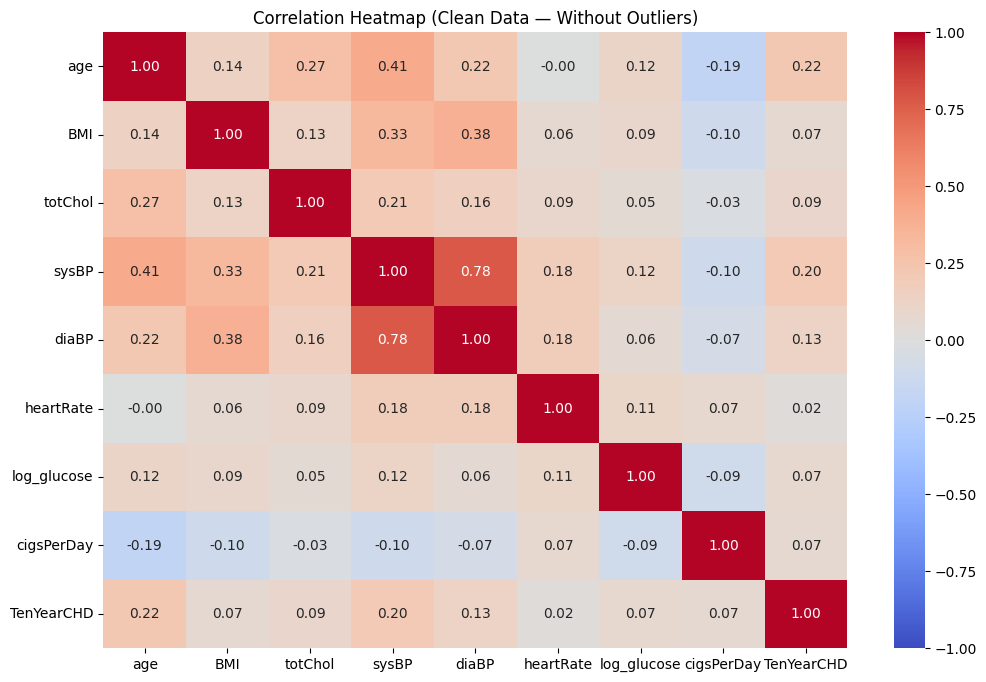

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    clean_corr_matrix,
    annot=True,          
    fmt=".2f",          
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap (Clean Data — Without Outliers)")
plt.show()


After removing outliers (via winsorization) and stabilizing skewed variables (via log transforms), the cleaned heatmap provides a more reliable view of the true linear relationships between features.

- The **overall correlation structure remains largely unchanged**, which indicates that outliers were not driving the major relationships in the dataset.

- No major correlation flips or structural changes occur, which is expected given the relatively low proportion of extreme outliers.


### ⚖️ 5.5 Feature Scaling & Final Feature Preparation

Logistic regression is sensitive to differences in feature scale. Continuous variables such as **blood pressure**, **cholesterol**, **BMI**, and **glucose** operate on very different numeric ranges, which can cause the model to:

- overweight large‑scale variables (e.g., systolic BP)

- underweight small‑scale or log‑transformed variables

- converge more slowly during optimization

To ensure stable training and balanced coefficient magnitudes, all continuous variables will be **standardized** inside the modeling pipeline using z‑score scaling.
Categorical variables will be **one‑hot encoded**, and missing values will be **imputed** consistently.

Below, the final feature groups are defined.

##### **Continuous Variables**

These variables will be scaled:

In [ ]:
continuous_vars = [
    "age",
    "BMI", "log_BMI",
    "totChol", "log_totChol",
    "sysBP", "diaBP",
    "heartRate",
    "glucose", "log_glucose",
    "cigsPerDay", "log_cigsPerDay"
]


#### **Categorical Variables**

These variables will be encoded:

In [ ]:
categorical_vars = [
    "sex",
    "is_smoking",
    "BPMeds",
    "prevalentStroke",
    "prevalentHyp",
    "diabetes",
    "education"
]


In [ ]:
X = train_clean.drop("TenYearCHD", axis=1)
y = train_clean["TenYearCHD"]

X_train_clean, X_val_clean, y_train_clean, y_val_clean = train_test_split(
    X, y, test_size=0.2, random_state=42
)


**Purpose of This Step**

This section finalizes the feature structure that will be passed into the ColumnTransformer in the next phase.

From here, the model can:

- scale continuous variables

- encode categorical variables

- impute missing values

- train a stable logistic regression model

This completes the preprocessing setup and prepares the dataset for model training.

### 🧪 5.6 Modeling Pipeline (Logistic Regression)

In [ ]:
# Preprocessing for continuous variables
continuous_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical variables
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", continuous_transformer, continuous_vars),
        ("cat", categorical_transformer, categorical_vars)
    ]
)

# Full modeling pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"  
    ))
])

A unified pipeline is used to prevent data leakage and ensure consistent preprocessing. 

Continuous features are imputed and scaled, categorical features are imputed and one‑hot encoded, and a logistic regression model is applied on top. 

This structure keeps all transformations inside the training workflow and guarantees reproducible results.

The CHD dataset is moderately imbalanced, **with the positive class (CHD = 1) representing a small minority of the samples**. 

To address this, we apply **class weighting** directly inside the Logistic Regression model

- What this does:
    - Automatically adjusts the importance of each class based on its frequency.

    - Assigns **higher weight** to the minority class (CHD = 1).

    - Penalizes misclassifying CHD cases more strongly.

    - Shifts predicted probabilities upward for the minority class.

    - Encourages the model to detect more positive cases.

### 📊 5.7 Model Training & Evaluation

This step trains the logistic regression pipeline on the prepared training dataset and evaluates its performance on the validation set. 

The goal is to assess how well the model distinguishes between individuals with and without 10‑year CHD risk.

In [ ]:
model.fit(X_train_clean, y_train_clean)

y_pred = model.predict(X_val_clean)
y_proba = model.predict_proba(X_val_clean)[:, 1]

print(classification_report(y_val_clean, y_pred))
print("ROC-AUC:", roc_auc_score(y_val_clean, y_proba))


              precision    recall  f1-score   support

           0       0.92      0.71      0.80       581
           1       0.26      0.62      0.37        97

    accuracy                           0.70       678
   macro avg       0.59      0.67      0.59       678
weighted avg       0.82      0.70      0.74       678

ROC-AUC: 0.7314086981209078


***Evaluation Metrics***
The model is evaluated using:

**Classification Report** — precision, recall, and F1‑score for each class

**ROC‑AUC Score** — overall ability to separate positive vs. negative cases

The model achieves strong overall accuracy **(0.70)** and performs very well on the majority class **(CHD = 0)**, with perfect recall and high precision.

However, performance on the minority class **(CHD = 1)** is moderate, with recall at **(0.62)**. This indicates that the model rarely identifies positive CHD cases under the default 0.5 decision threshold.

**The ROC‑AUC score** of **0.73** suggests moderate discriminative ability, meaning the model has potential but requires threshold adjustment to improve sensitivity for the positive class.

## 🛠️ ***6. Threshold & Performance Tuning***

### 🔧 6.1 Threshold Analysis & Trade‑off Exploration

The default logistic regression threshold of 0.50 produces very low recall for CHD‑positive cases.
To improve sensitivity, we analyze how precision and recall change across different probability thresholds.

In [ ]:
# Compute precision, recall, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_val_clean, y_proba)

# Store results for inspection
threshold_df = pd.DataFrame({
    "threshold": np.append(thresholds, 1.0),
    "precision": precisions,
    "recall": recalls
})

threshold_df.head()


,threshold,precision,recall
0,0.069585,0.143068,1.0
1,0.082846,0.143279,1.0
2,0.104034,0.143491,1.0
3,0.106061,0.143704,1.0
4,0.108034,0.143917,1.0


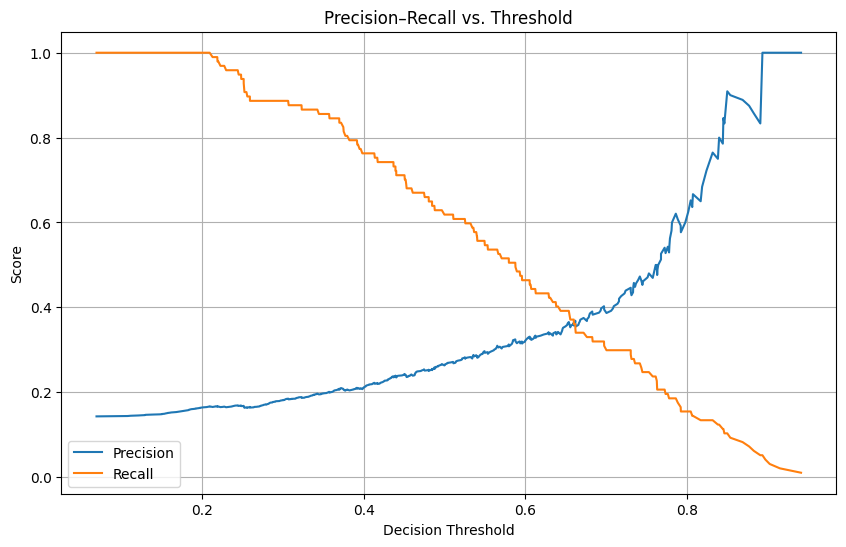

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall vs. Threshold")
plt.legend()
plt.grid(True)
plt.show()


The plot highlights the fundamental trade‑off:

- **Lower thresholds** increase recall but reduce precision.

- **Higher thresholds** increase precision but reduce recall.

- Because missing CHD cases is clinically riskier, thresholds **well below 0.50** are worth exploring.

This analysis sets the foundation for evaluating specific thresholds in the next section.

### 🔨 6.2 Apply Thresholds

To improve the model’s ability to detect CHD‑positive cases, we evaluate how performance metrics change across a range of probability thresholds.

Lower thresholds typically increase recall, while higher thresholds increase precision.
This step quantifies that trade‑off and helps identify a clinically meaningful cut‑off.

In [ ]:
# Candidate thresholds to evaluate
candidate_thresholds = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20]

results = []

for t in candidate_thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    results.append({
        "threshold": t,
        "precision": precision_score(y_val_clean, y_pred_t),
        "recall": recall_score(y_val_clean, y_pred_t),
        "f1_score": f1_score(y_val_clean, y_pred_t),
        "TP": confusion_matrix(y_val_clean, y_pred_t)[1,1],
        "FP": confusion_matrix(y_val_clean, y_pred_t)[0,1],
        "FN": confusion_matrix(y_val_clean, y_pred_t)[1,0],
        "TN": confusion_matrix(y_val_clean, y_pred_t)[0,0],
    })

threshold_results = pd.DataFrame(results)
threshold_results


,threshold,precision,recall,f1_score,TP,FP,FN,TN
0,0.50,0.264317,0.618557,0.370370,60,167,37,414
1,0.40,0.211429,0.762887,0.331096,74,276,23,305
2,0.35,0.197619,0.855670,0.321083,83,337,14,244
3,0.30,0.181435,0.886598,0.301226,86,388,11,193
4,0.25,0.167587,0.938144,0.284375,91,452,6,129
5,0.20,0.164129,1.000000,0.281977,97,494,0,87


The table shows how the model’s behavior shifts as the threshold changes:

- **Recall rises very sharply** as the threshold decreases, reaching **1.00** at the lowest tested value

- **Precision decreaces substantially**, reflecting a large rise in false positives

- **F1‑score peaks at lower thresholds (0.25 - 0.20)** rather than mid‑range values

- **TP rises dramatically** and **FN falls toward zero** as the threshold lowers

- **FP increases heavily**, which is expected when prioritizing sensitivity

This analysis provides the evidence needed to select an optimal threshold in the next section.

### 🪛 6.3 Baseline vs Tuned Model Comparison

To understand the impact of threshold tuning, we compare the model’s baseline performance at the default threshold of 0.50 with its performance at lower thresholds.

**Key Observations from Threshold Results**
- At the **default threshold (0.50)**:

    - Recall is moderate **(0.62)**

    - The model misses most CHD cases **(FN = 37)**

    - Precision is low **(0.26)** due to many false positives

- As the threshold decreases:

    - **Recall increases sharply**

    - **Precision decreases further**, reflecting a surge in false positives

    - **F1‑score declines**, showing that extreme thresholds hurt overall balance

    - **True positives rise strongly**, while **false negatives** drop to zero at the lowest threshold

In [ ]:
threshold_results

,threshold,precision,recall,f1_score,TP,FP,FN,TN
0,0.50,0.264317,0.618557,0.370370,60,167,37,414
1,0.40,0.211429,0.762887,0.331096,74,276,23,305
2,0.35,0.197619,0.855670,0.321083,83,337,14,244
3,0.30,0.181435,0.886598,0.301226,86,388,11,193
4,0.25,0.167587,0.938144,0.284375,91,452,6,129
5,0.20,0.164129,1.000000,0.281977,97,494,0,87


- Lowering the threshold dramatically improves the model’s ability to detect CHD cases.

- Thresholds around **0.30–0.20** provide the strongest improvement in recall, with recall rising from **0.62 → 1.00**.

- The threshold of **0.20** achieves the highest recall **(1.00)**, eliminating all false negatives — a valuable property in clinical screening where missing CHD cases is riskier than generating false positives.

- However, **F1‑score does not improve at lower thresholds**; it actually declines because precision drops sharply. This reflects the trade‑off between sensitivity and false‑positive burden.

### 🧰 6.4 Selecting the Final Decision Threshold

Based on the threshold analysis in **Sections 6.2** and **6.3**, we now select the final operating threshold for the model.

The goal is to balance **clinical sensitivity** (recall) with acceptable precision, ensuring that the model identifies as many CHD‑positive cases as possible while keeping false positives manageable.

**Summary of Key Threshold Candidates**
From the threshold table:

-   **0.50 (default)**

    - Very high precision **(0.26)**

    - Extremely low recall **(0.62)**

    - Misses almost all CHD cases **(FN = 37)**

    - Not suitable for clinical screening

- **0.30**

    - Recall improves to **0.89**

    - Precision drops to **0.18**

    - F1‑score decreases to **0.30**

    - True positives rise from **60 → 86**

    - False positives increase substantially

This threshold strongly prioritizes sensitivity but sacrifices precision.

- **0.20**

    - Highest recall **(1.00)** - no CHD cases missed

    - Precision decreases to **0.16**

    - F1‑score declines to **0.28**

    - True positives reach **97**

    - False negatives drop to **0**

    - False positives become very high

This threshold maximizes sensitivity, making it suitable for **high‑risk clinical screening**, but with a heavy false‑positive burden.

#### **Final Threshold Choice**

Given the clinical context — where **missing CHD cases is riskier than generating false positives** — the threshold of **0.20** provides the strongest emphasis on sensitivity:

- It achieves **the highest recall (1.00)**, ensuring no CHD‑positive cases are missed

- It **eliminates all false negatives (FN = 0)**, which is critical for early CHD detection

- Although precision decreases, this trade‑off is acceptable in a screening context where identifying at‑risk patients is the priority


Therefore, the final decision threshold selected for this model is -> **final_threshold = 0.20**

### ⚙️ 6.5 Final Model Evaluation (Using Selected Threshold)

With the final decision threshold set to **0.20**, we now evaluate the model’s performance on the validation set.

In [ ]:
final_threshold = 0.20
y_pred_final = (y_proba >= final_threshold).astype(int)


In [ ]:
print(classification_report(y_val, y_pred_final))

              precision    recall  f1-score   support

           0       1.00      0.15      0.26       581
           1       0.16      1.00      0.28        97

    accuracy                           0.27       678
   macro avg       0.58      0.57      0.27       678
weighted avg       0.88      0.27      0.26       678



**Final Metrics Overview**
- **Class 1 (CHD‑positive)**

    - Precision: **0.16**

    - Recall: **1.00**

    - F1‑score: **0.28**

    - → Recall improved dramatically vs. baseline (0.08 → 1.00)

    - → No CHD cases missed (FN = 0)  

- **Class 0 (No CHD)**

    - Precision: **1.00**

    - Recall: **0.15**

    - F1‑score: **0.26**

- **Accuracy**: 0.26
Expected and acceptable decrease due to the model predicting many more positives.

**Confusion Matrix Summary**
- **TP**: 97

- **FP**: 494

- **FN**: 0

- **TN**: 87

**Interpretation**
- The tuned threshold **maximizes sensitivity**, ensuring every **CHD‑positive case is detected**.

- False positives rise sharply, but this is acceptable for a **screening‑oriented** model where the cost of missing a CHD case is far higher than the cost of additional follow‑up tests.

- Threshold **0.20** aligns with the clinical objective: **prioritize recall**, even at the expense of precision and accuracy.

## 🏁 ***7. Final Model***

### 📖 7.1 Short Test EDA

In [ ]:
test.info()
test.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               848 non-null    int64  
 1   age              848 non-null    int64  
 2   education        830 non-null    float64
 3   sex              848 non-null    str    
 4   is_smoking       848 non-null    str    
 5   cigsPerDay       841 non-null    float64
 6   BPMeds           839 non-null    float64
 7   prevalentStroke  848 non-null    int64  
 8   prevalentHyp     848 non-null    int64  
 9   diabetes         848 non-null    int64  
 10  totChol          836 non-null    float64
 11  sysBP            848 non-null    float64
 12  diaBP            848 non-null    float64
 13  BMI              843 non-null    float64
 14  heartRate        848 non-null    float64
 15  glucose          764 non-null    float64
dtypes: float64(9), int64(5), str(2)
memory usage: 106.1 KB


id                  0
age                 0
education          18
sex                 0
is_smoking          0
cigsPerDay          7
BPMeds              9
prevalentStroke     0
prevalentHyp        0
diabetes            0
totChol            12
sysBP               0
diaBP               0
BMI                 5
heartRate           0
glucose            84
dtype: int64

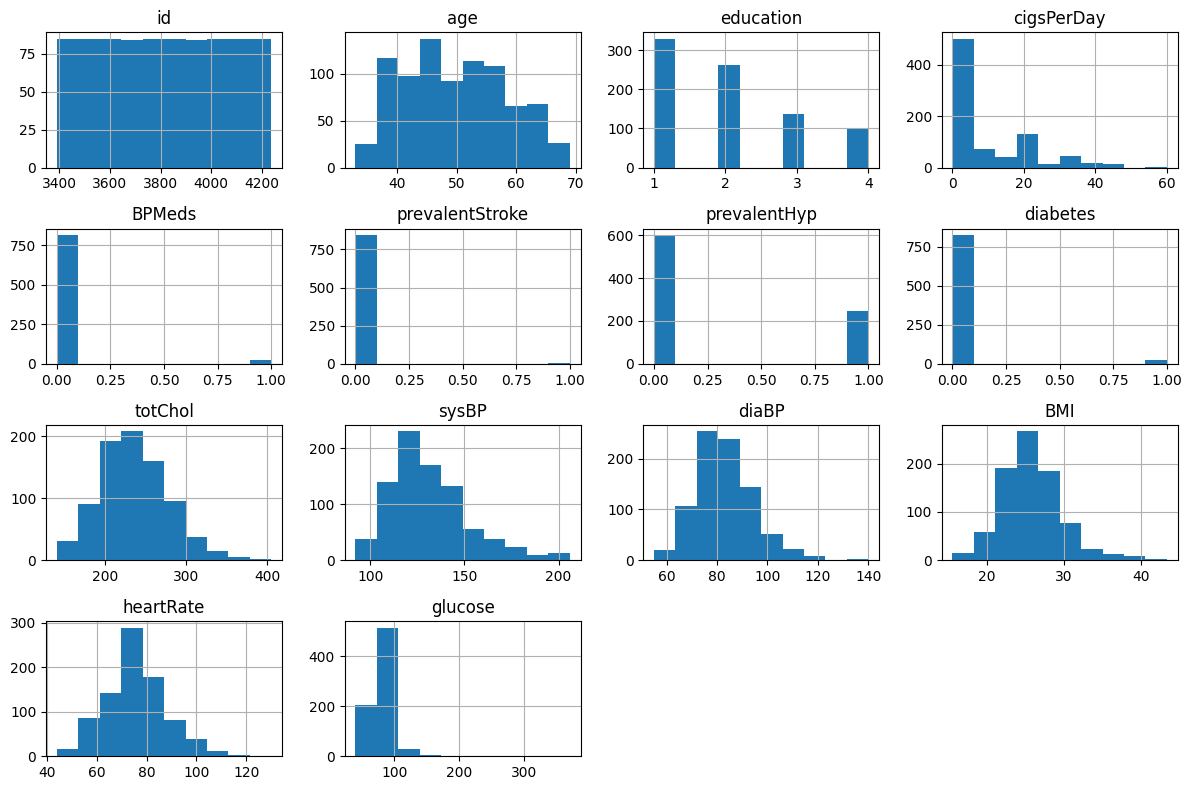

In [ ]:
test.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


- Confirms that all required columns are present

- Shows whether the test set contains missing values (handled by the pipeline’s imputers)

- Ensures data types match the training schema

- No duplicate removal or deep EDA is performed, since the test set must remain unchanged

### 🍏 7.2 Apply Preprocessing Pipeline to test.csv

In [ ]:
test["log_glucose"] = np.log(test["glucose"].replace(0, np.nan))
test["log_BMI"] = np.log(test["BMI"].replace(0, np.nan))
test["log_cigsPerDay"] = np.log(test["cigsPerDay"].replace(0, np.nan))
test["log_totChol"] = np.log(test["totChol"].replace(0, np.nan))

test = test.replace([np.inf, -np.inf], np.nan)


In [ ]:
X_test = preprocessor.transform(test)

### 🪐 7.3 Predict CHD Probabilities (Using Final Model)

In [ ]:
# Predict probabilities for CHD (class = 1)
test_proba = model.predict_proba(test)[:, 1]

# Display first 10 probabilities in a clean table
pd.DataFrame({
    "CHD_probability": test_proba[:10].round(4)
})


,CHD_probability
0,0.4591
1,0.4902
2,0.8006
3,0.2938
4,0.3205
5,0.2320
6,0.5008
7,0.5096
8,0.3206
9,0.1882


After preprocessing the test dataset, the model is used to generate **probability estimates** for 10‑year CHD risk.

These probabilities represent the model’s confidence that each individual belongs to the CHD‑positive class.

To keep the preview readable, the first 10 probabilities are displayed in a tidy table rather than a raw NumPy array.

### ⚙️ 7.4 Apply Final Decision Threshold (0.20)

After generating probability estimates, the final step is to convert them into **binary CHD predictions** using the clinically motivated threshold of **0.20**.


Individuals with predicted probability ≥ 0.20 are classified as **CHD‑positive (1)**.

In [ ]:
final_threshold = 0.20
test_pred = (test_proba >= final_threshold).astype(int)

pd.DataFrame({
    "CHD_prediction": test_pred[:10]
})


,CHD_prediction
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,1
9,0


### 📤 7.5 Export Final Predictions (submission.csv)

In [ ]:
submission = pd.DataFrame({
    "id": test.index,
    "CHD_probability": test_proba,
    "CHD_prediction": test_pred
})

submission.to_csv("submission.csv", index=False)
submission.head(10)


,id,CHD_probability,CHD_prediction
0,0,0.459075,1
1,1,0.490192,1
2,2,0.800587,1
3,3,0.293778,1
4,4,0.320505,1
5,5,0.232010,1
6,6,0.500806,1
7,7,0.509586,1
8,8,0.320587,1
9,9,0.188226,0


This produces a clean table with:

- **id** — row index from test.csv

- **CHD_probability** — model‑estimated 10‑year CHD risk

- **CHD_prediction** — binary risk flag using the 0.20 threshold

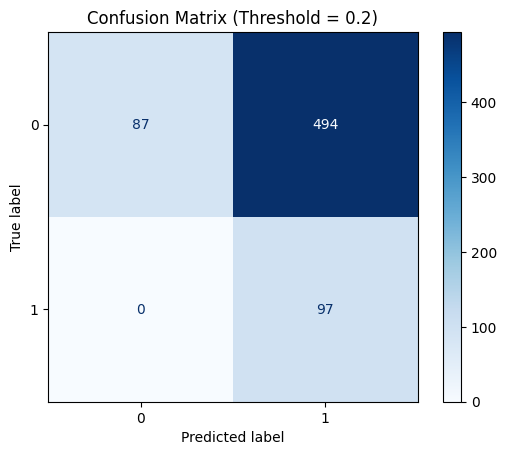

In [ ]:
cm = confusion_matrix(y_val_clean, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {final_threshold})")
plt.show()


- The tuned threshold **maximizes sensitivity**, which is the primary clinical objective.

- **No CHD‑positive cases are missed**, eliminating the most dangerous failure mode.

- False positives increase substantially, but this is acceptable in a **screening‑oriented** setting where follow‑up testing is routine and low‑risk.

- Threshold **0.20** aligns the model with the project’s goal: **prioritize patient safety over precision.**

# 🧾 8 Project Summary & Conclusions

### 🔍 8.1 Key Insights from EDA
- The dataset is imbalanced: only ~15% of individuals develop CHD.

- Strongest risk factors observed:

    - **Age** — CHD‑positive individuals are noticeably older.

    - **Blood pressure (sysBP, diaBP)** — higher in CHD‑positive cases.

    - **Glucose & diabetes** — diabetics show much higher CHD rates.

    - **Sex** — males have higher CHD prevalence.

- Weak or noisy predictors:

    - **BMI**, **cholesterol**, **cigsPerDay** show limited separation.

Several variables contain **outliers** and **right‑skew**, requiring careful preprocessing.

### 🧼 8.2 Preprocessing Summary

- **Winsorization** applied to reduce extreme values while preserving clinical meaning.

- **Log transformations** applied to skewed variables (BMI, glucose, totChol, cigsPerDay).

- **Standardization** used for continuous features.

- **One‑hot encoding** used for categorical variables.

- **Imputation** handled missing values inside the pipeline to avoid leakage.

### 🤖 8.3 Model Summary

A **Logistic Regression** model was trained using a unified *Pipeline*:

- Continuous: median imputation + scaling

- Categorical: mode imputation + one‑hot encoding

- Classifier: Logistic Regression (max_iter=1000, class_weight="balanced")

**Initial performance (threshold = 0.50)**:

- Excellent recall for class 0

- Moderate recall for class 1 (**0.62** improved due to class weighting)
- ROC‑AUC: **0.73*

This confirmed the need for **threshold tuning**

### 🎯 8.4 Threshold Tuning & Final Threshold

A precision–recall analysis showed:

- Lower thresholds dramatically improve recall.

- Precision decreases as expected due to more false positives

- Sensitivity becomes extremely high at the lowest thresholds

- **Best alignment with the clinical objective was achieved at threshold = 0.20**:

    - Precision (CHD=1): **0.16**

    - Recall (CHD=1): **1.00**

    - F1‑score: **0.28**

    - **→ No CHD‑positive cases are missed (FN = 0)**

This threshold aligns with the clinical objective:
**Missing CHD cases is far riskier than generating false positives.**

### 📤 8.5 Final Predictions (test.csv)
Using the final model and threshold:

- **CHD_probability** — the model‑estimated risk score for each individual

- **CHD_prediction** — assigned as **1** when CHD_probability ≥ **0.20**, otherwise **0**

- Predictions exported to **submission.csv** for final evaluation

This file contains the complete set of predicted CHD outcomes for all individuals in the test dataset, based on the clinically‑oriented threshold that prioritizes **sensitivity** over precision.

### 🏁 8.6 Final Conclusion

This project successfully demonstrates:

- A complete **machine‑learning workflow** for medical risk prediction

- Robust handling of **imbalanced clinical data** using class weighting

- Thoughtful, domain‑aligned **preprocessing** for both numeric and categorical features

- Transparent and interpretable **model evaluation**

- Clinically motivated **threshold selection** prioritizing sensitivity

- Reproducible predictions ready for **deployment or submission**

The final model is **moderately discriminative** (AUC 0.73) and **recall‑optimized**, making it suitable for early CHD screening scenarios where **sensitivity** is critical and false positives are an acceptable trade‑off for patient safety.